In [186]:
import mplhep
mplhep.style.use('ROOT')
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import hist
import numpy as np
import uproot

class HistFile:
    def __init__(self, fp, ana, **kwargs):
        self._file = uproot.open(fp, **kwargs)
        self._ana = ana
        self._ana_dir = self._file[self._ana]

    def keys(self):
        return [
            key.removeprefix(f'{self._ana}_').removesuffix(';1')
            for key in self._ana_dir.keys()
        ]

    def __getitem__(self, item):
        if item in self._ana_dir:
            return self._ana_dir[item]
        if item in self._file:
            return self._file[item]
        return self._ana_dir[f'{self._ana}_{item}']

In [223]:
f= HistFile('hist.root', 'SkimZoneTrackAnalyzer')

In [224]:
f.keys()

['impact_point',
 'leadtrk_impact_point',
 'leadtrk_nhits_10_impact_point',
 'leadtrk_nhits_10_neg_charge_impact_point',
 'reco_momentum',
 'sim_momentum',
 'esph_momentum',
 'reco_leadtrk_momentum',
 'reco_leadtrk_momentum_all_reqs',
 'leadtrk_reco_vs_sim_momentum',
 'leadtrk_reco_vs_esph_momentum',
 'leadtrk_reco_vs_lead_electron_energy',
 'leadtrk_reco_vs_sim_momentum_all_reqs',
 'leadtrk_reco_all_reqs_vs_Energy_Estimate_Beamspot',
 'leadtrk_reco_all_reqs_vs_ecal_energy',
 'leadtrk_reco_all_reqs_vs_ecal_energy_zone_1',
 'leadtrk_reco_all_reqs_vs_ecal_energy_zone_2',
 'leadtrk_reco_all_reqs_vs_ecal_energy_zone_3',
 'leadtrk_reco_all_reqs_vs_ecal_energy_zone_4',
 'leadtrk_reco_all_reqs_vs_ecal_energy_zone_5',
 'difference_Beamspot',
 'energy_diff_vs_chi2_Beamspot',
 'energy_estimate_vs_ecal_energy',
 'ecal_energy',
 'ecal_energy_zone_1',
 'ecal_energy_zone_2',
 'ecal_energy_zone_3',
 'ecal_energy_zone_4',
 'ecal_energy_zone_5',
 'max_pe']

In [225]:
#smear['reco_leadtrk_momentum'].to_hist().plot(density=True, label='Smear (mostly 10 hits)')
#no_smear['reco_leadtrk_momentum'].to_hist().plot(density=True, label='No Smear (mostly 8 hits)')
#plt.ylabel('A.U. (Integral = 1)')
#plt.legend()
#plt.savefig("smear_vs_no_smear_leadtrk_momentum_1D.jpg")

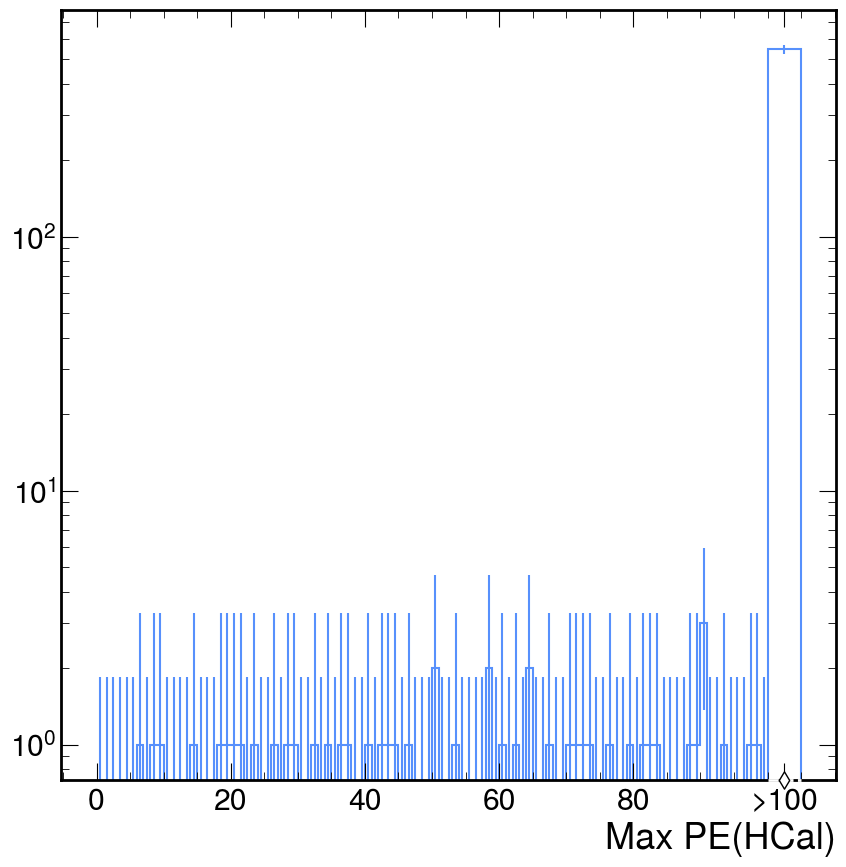

In [229]:
g = f['max_pe'].to_hist().plot(flow='show')
plt.yscale('log')
#plt.xlim(0,10)
#plt.title("Zone 0")
plt.savefig("blah-log.jpg")

/export/scratch/users/rodr1001/my_code/my_code/ldmx/EAT_Tracking/.venv/lib64/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/export/scratch/users/rodr1001/my_code/my_code/ldmx/EAT_Tracking/.venv/lib64/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/export/scratch/users/rodr1001/my_code/my_code/ldmx/EAT_Tracking/.venv/lib64/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/export/scratch/users/rodr1001/my_code/my_code/ldmx/EAT_Tracking/.venv/lib64/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  retu

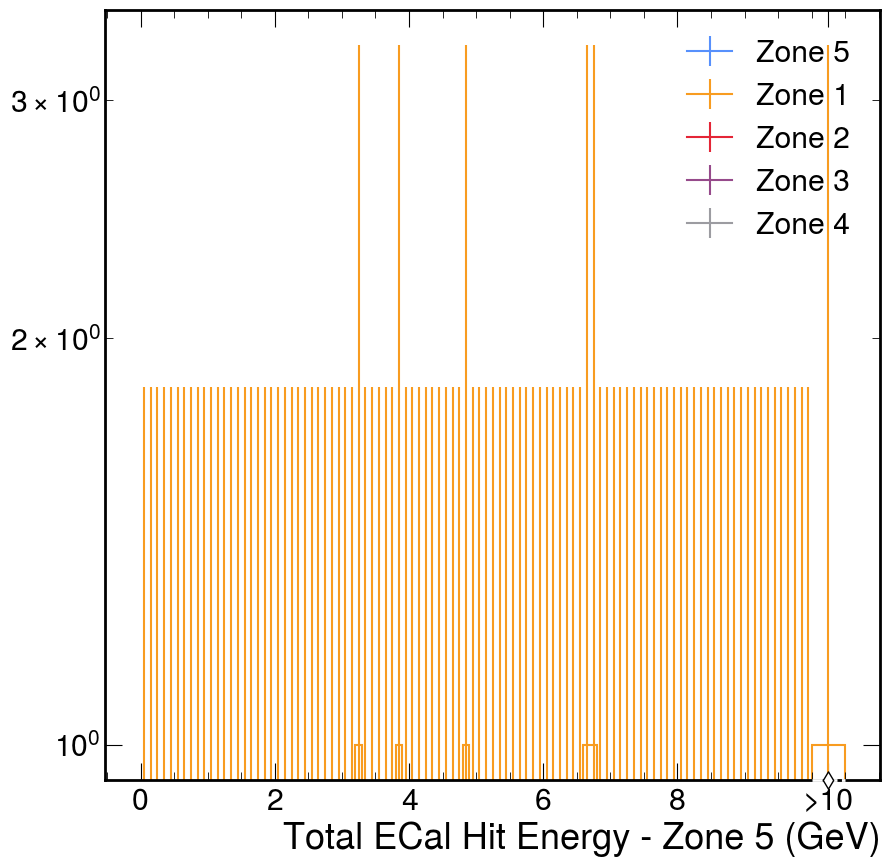

In [160]:
g = f['ecal_energy_zone_5'].to_hist().plot(flow='show', label = "Zone 5")
q =f['ecal_energy_zone_1'].to_hist().plot(flow='show', label = "Zone 1")
d =f['ecal_energy_zone_2'].to_hist().plot(flow='show', label = "Zone 2")
z=f['ecal_energy_zone_3'].to_hist().plot(flow='show', label = "Zone 3")
b =f['ecal_energy_zone_4'].to_hist().plot(flow='show', label = "Zone 4")

plt.yscale("log")
plt.legend(loc='best')
#plt.savefig("ecal-energy-zones.jpg")

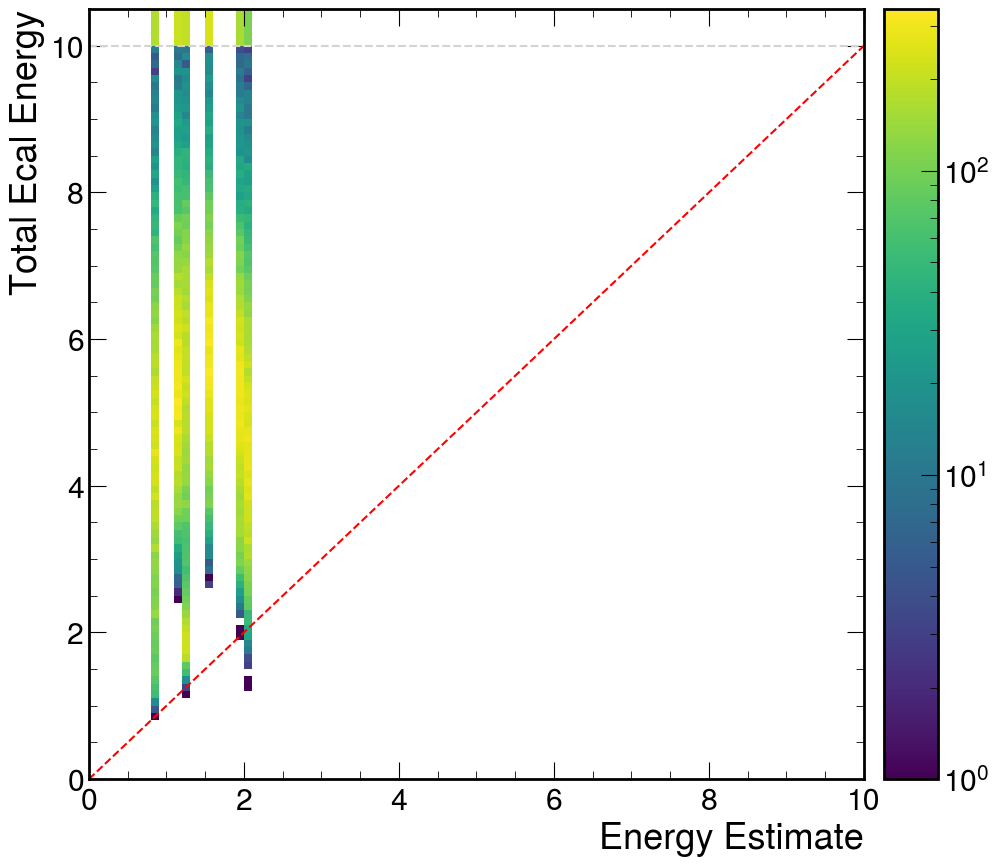

In [201]:
g = f['energy_estimate_vs_ecal_energy'].to_hist().plot(norm='log',flow='show')
plt.axline((0, 0), slope=1,color="red", linestyle="--")

#plt.savefig("ecal_energy_vs_estimate_1M.jpg")

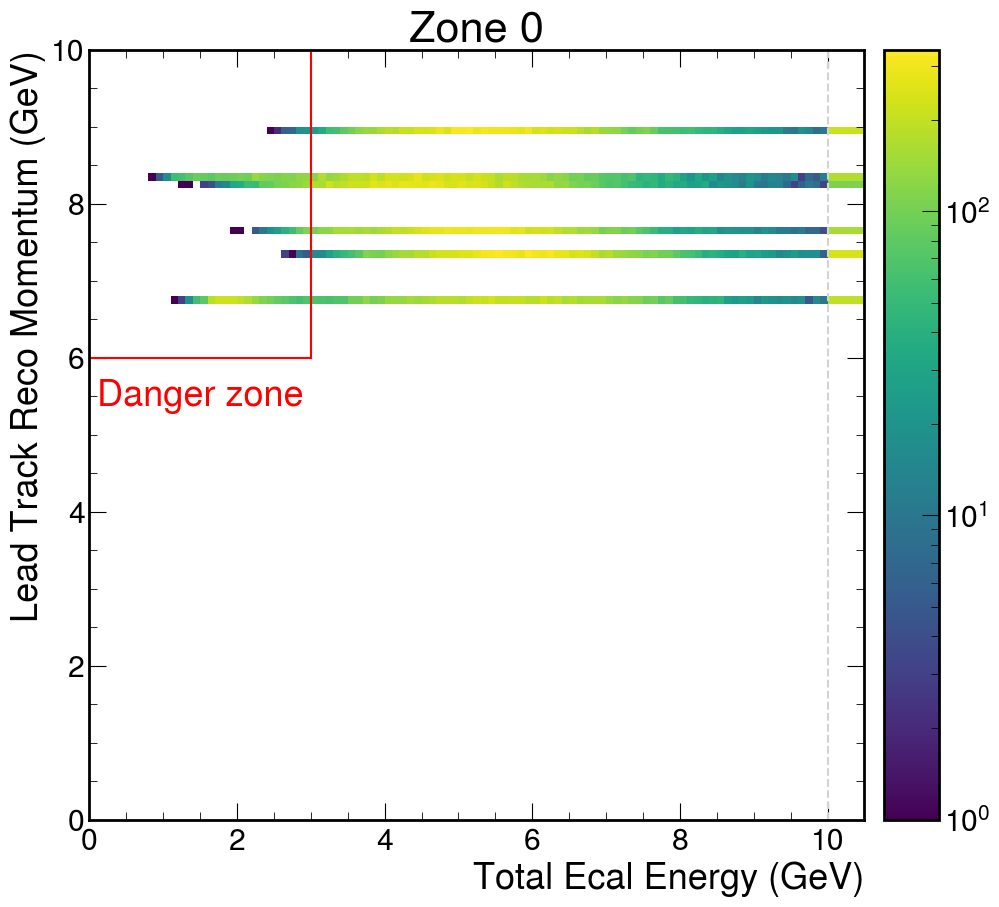

In [203]:
g = f['leadtrk_reco_all_reqs_vs_ecal_energy_zone_1'].to_hist().plot(norm='log',flow='show')
#plt.axline((0, 0), slope=1,color="red", linestyle="--")
plt.title ("Zone 0")
plt.plot([3,0], [6,6], color='red')
plt.text(1.5, 5.5, "Danger zone", ha='center', va='center', color ='red')
plt.plot([3, 3], [10, 6], color='red')
plt.savefig("leadtrk_reco_all_reqs_vs_ecal_energy_zone_0.jpg")

In [ ]:
g = f['leadtrk_reco_all_reqs_vs_ecal_energy_zone_2'].to_hist().plot(norm='log',flow='show')
plt.axline((0, 0), slope=1,color="red", linestyle="--")
plt.title ("Zone 2")

#plt.savefig("leadtrk_reco_all_reqs_vs_ecal_energy_zone_2.jpg")

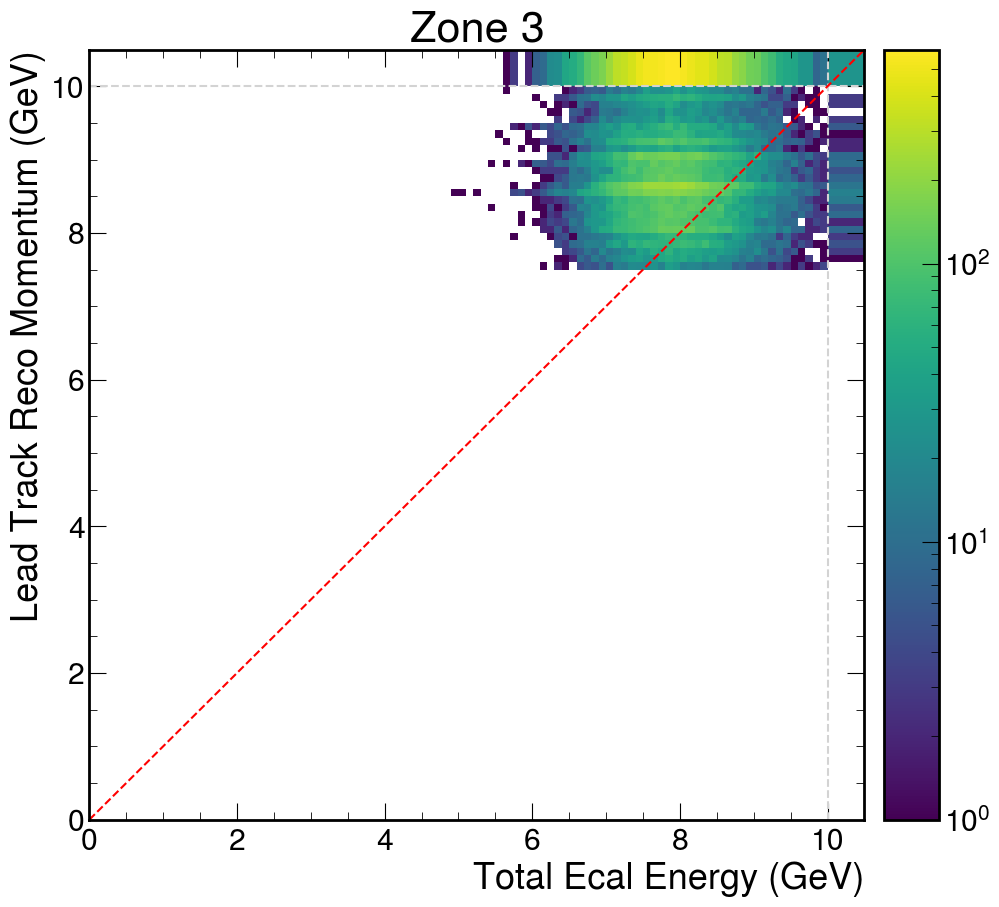

In [103]:
g = f['leadtrk_reco_all_reqs_vs_ecal_energy_zone_3'].to_hist().plot(norm='log',flow='show')
plt.axline((0, 0), slope=1,color="red", linestyle="--")
plt.title ("Zone 3")

#plt.savefig("leadtrk_reco_all_reqs_vs_ecal_energy_zone_3.jpg")

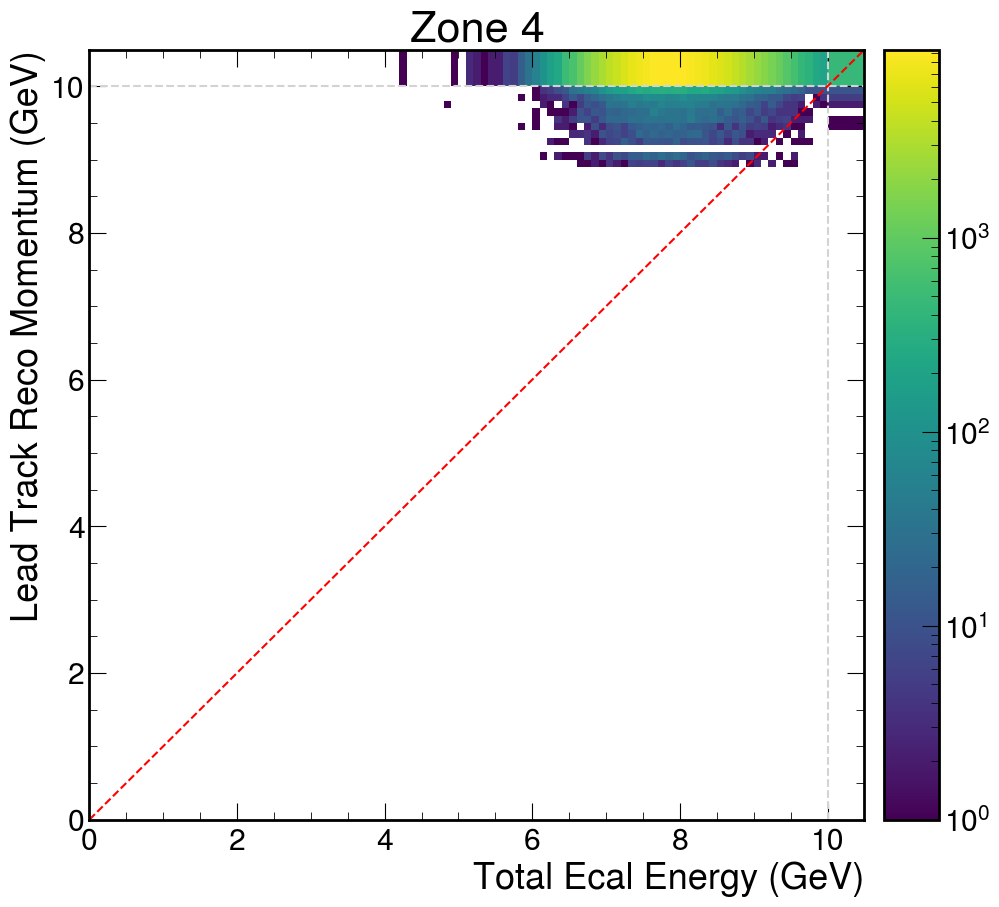

In [104]:
g = f['leadtrk_reco_all_reqs_vs_ecal_energy_zone_4'].to_hist().plot(norm='log',flow='show')
plt.axline((0, 0), slope=1,color="red", linestyle="--")
plt.title ("Zone 4")

plt.savefig("leadtrk_reco_all_reqs_vs_ecal_energy_zone_4.jpg")

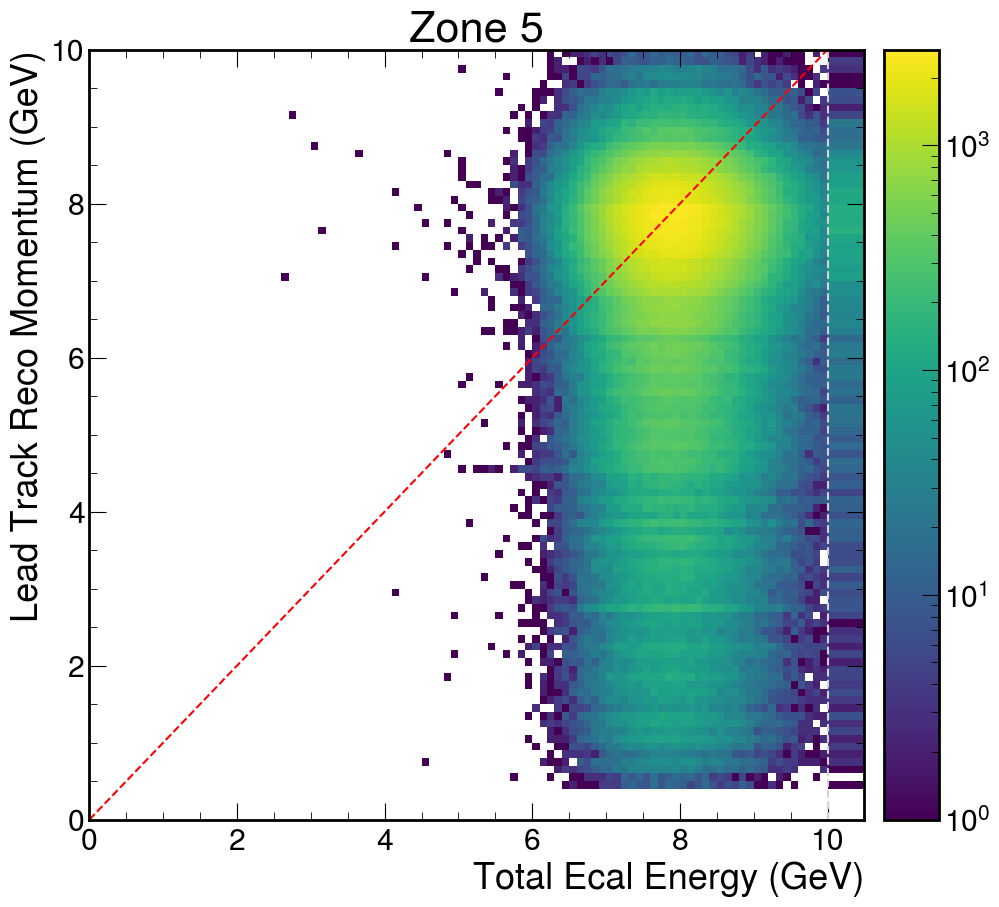

In [105]:
g = f['leadtrk_reco_all_reqs_vs_ecal_energy_zone_5'].to_hist().plot(norm='log',flow='show')
plt.axline((0, 0), slope=1,color="red", linestyle="--")
plt.title ("Zone 5")

plt.savefig("leadtrk_reco_all_reqs_vs_ecal_energy_zone_5.jpg")

Text(4, 7, 'Zone 1')

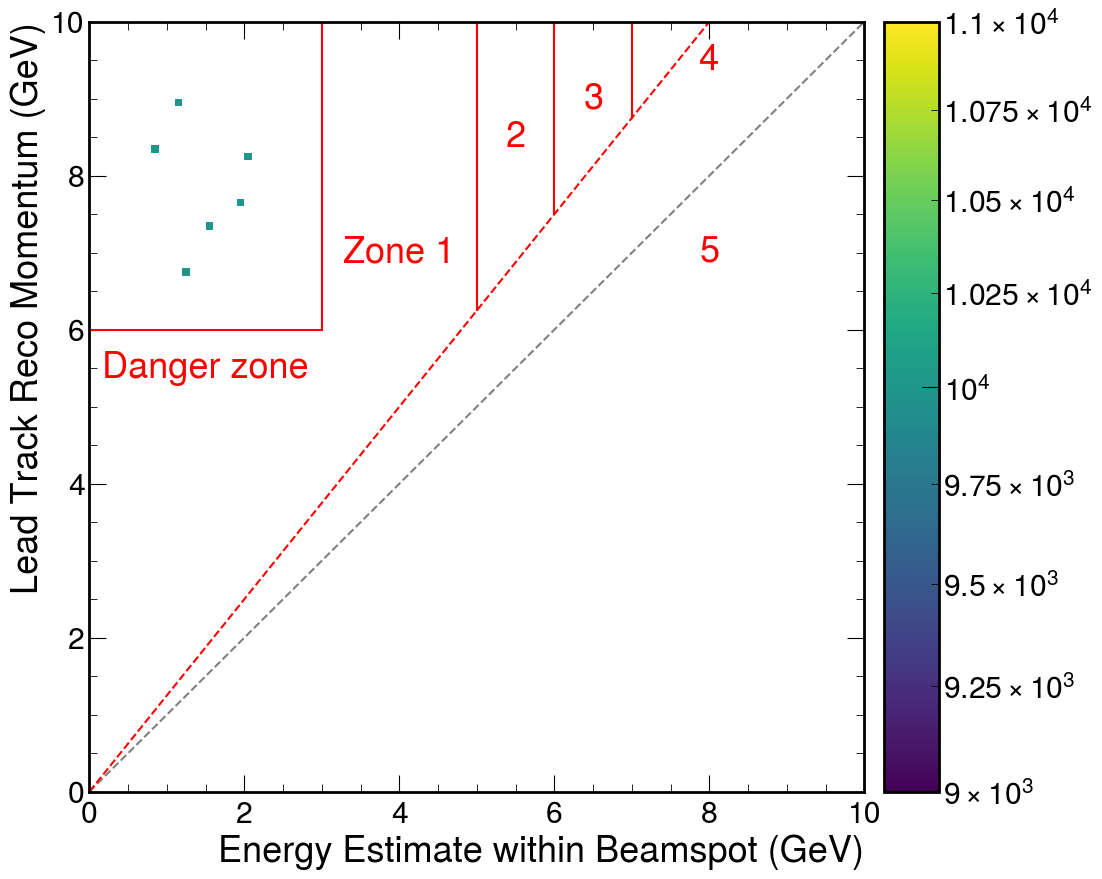

In [153]:
g = f['leadtrk_reco_all_reqs_vs_Energy_Estimate_Beamspot'].to_hist().plot(norm='log',flow='show')
plt.axline((0, 0), slope=1,color="gray", linestyle="--")
plt.axline((0, 0), slope=1.25,color="red", linestyle="--")
plt.plot([5, 5], [10, 1.25*5], color='red')
plt.plot([6, 6], [10, 1.25*6], color='red')
plt.plot([7, 7], [10, 1.25*7], color='red')

plt.plot([3, 3], [10, 6], color='red')
plt.plot([3,0], [6,6], color='red')
plt.text(1.5, 5.5, "Danger zone", ha='center', va='center', color ='red')

plt.text(5.5, 8.5, "2", ha='center', va='center', color ='red')
plt.text(6.5, 9, "3", ha='center', va='center', color ='red')
plt.text(8, 9.5, "4", ha='center', va='center', color ='red')
plt.text(8, 7, "5", ha='center', va='center', color ='red')

plt.text(4, 7, "Zone 1", ha='center', va='center', color ='red')

#plt.axline((0, 0), slope=1.25,color="red", linestyle="--")


#plt.savefig("leadtrk_reco_all_reqs_vs_energy_estimate_1M.jpg")

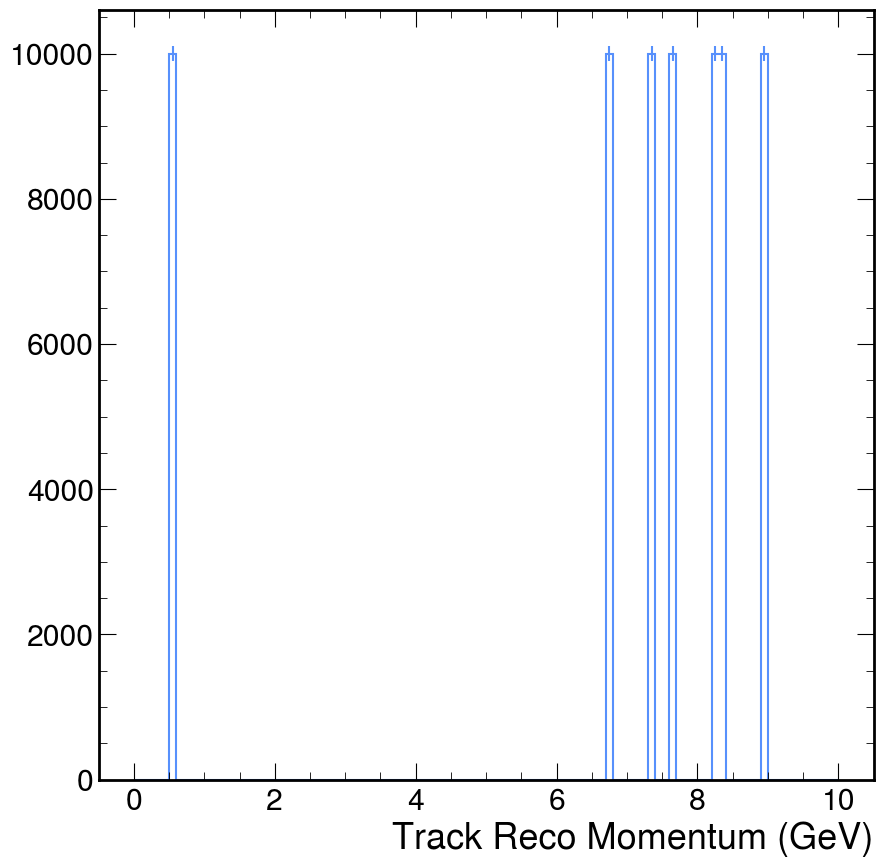

In [133]:
g = f['reco_momentum'].to_hist().plot()
#h = f['sim_momentum'].to_hist().plot()
#plt.savefig("reco_momentum_SAMPLE.jpg")

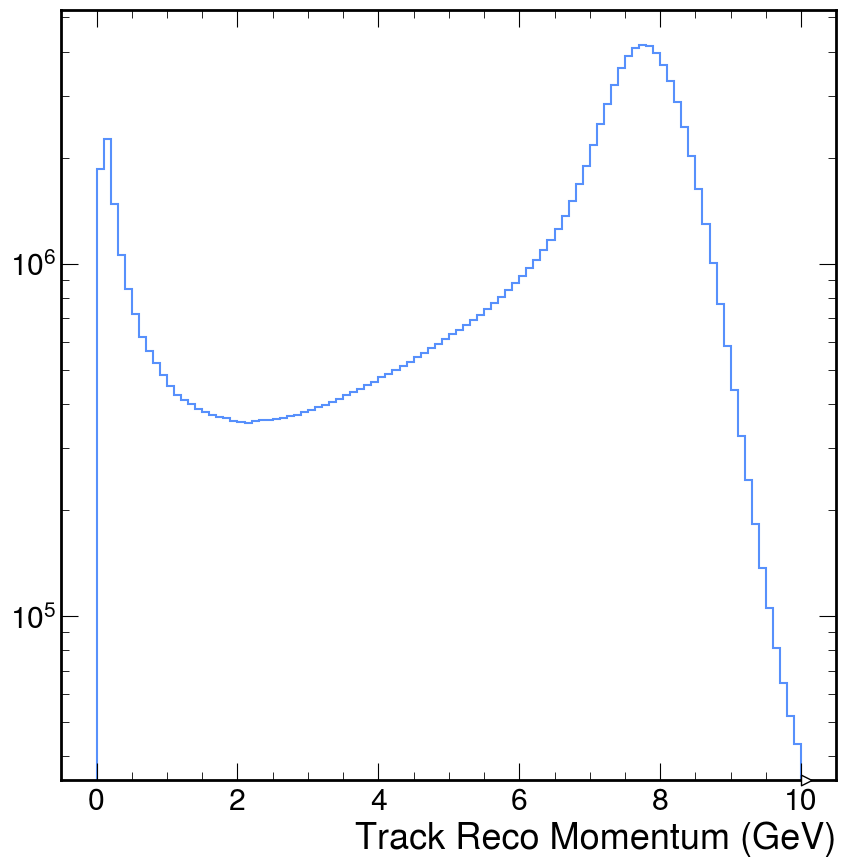

In [10]:
g = f['reco_momentum'].to_hist().plot()
plt.yscale('log')

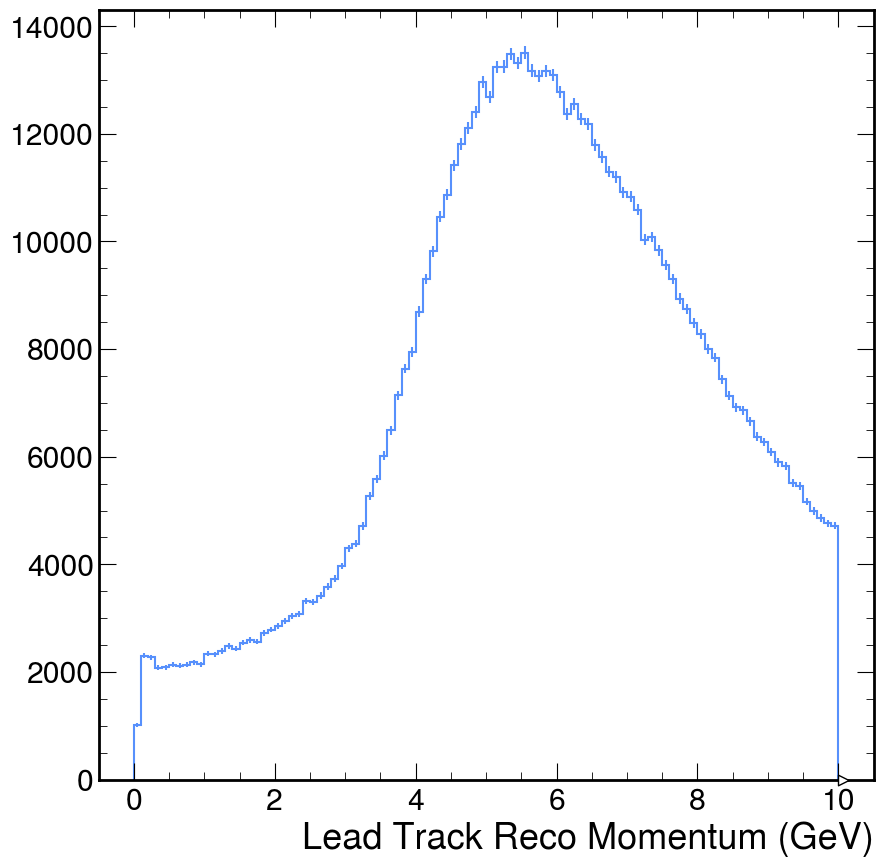

In [77]:
g = f['reco_leadtrk_momentum'].to_hist().plot()
#plt.savefig("leadtrk_reco_momentum.jpg")

Text(1, 0, 'Reco Track Momentum [GeV]')

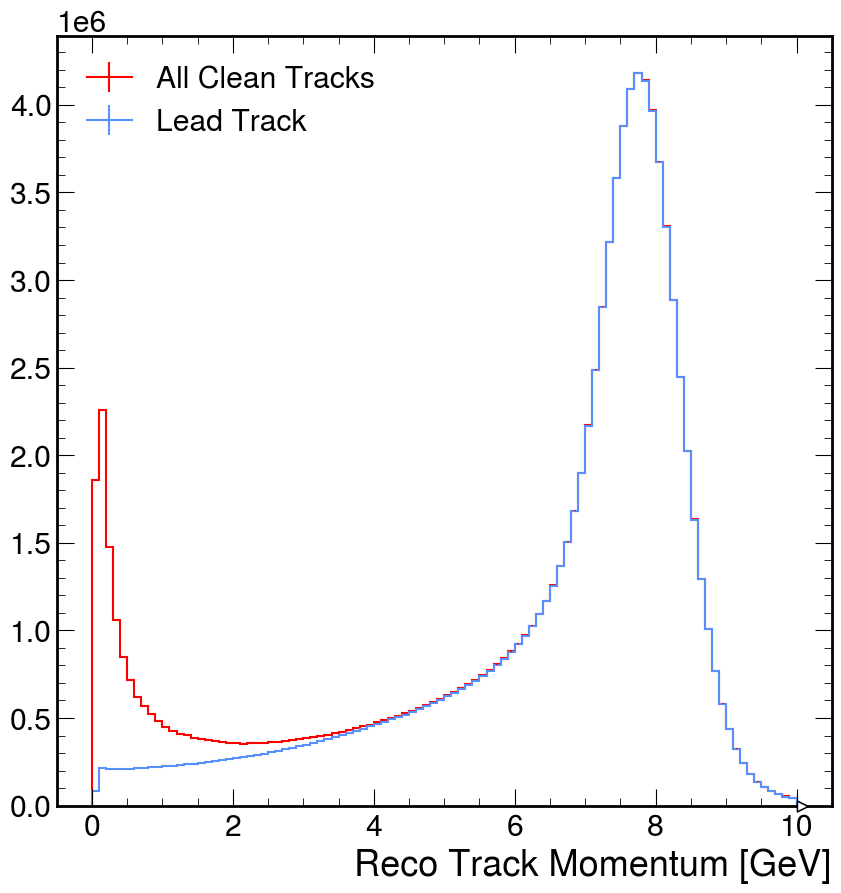

In [11]:
hh = f['reco_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "All Clean Tracks")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track")
plt.legend(loc='best')
plt.xlabel('Reco Track Momentum [GeV]')
#plt.ylim(0,5000)
#plt.yscale("log")
#plt.savefig("1M_clean_vs_leadtrk_reco_1D-SAMPLE.jpg")

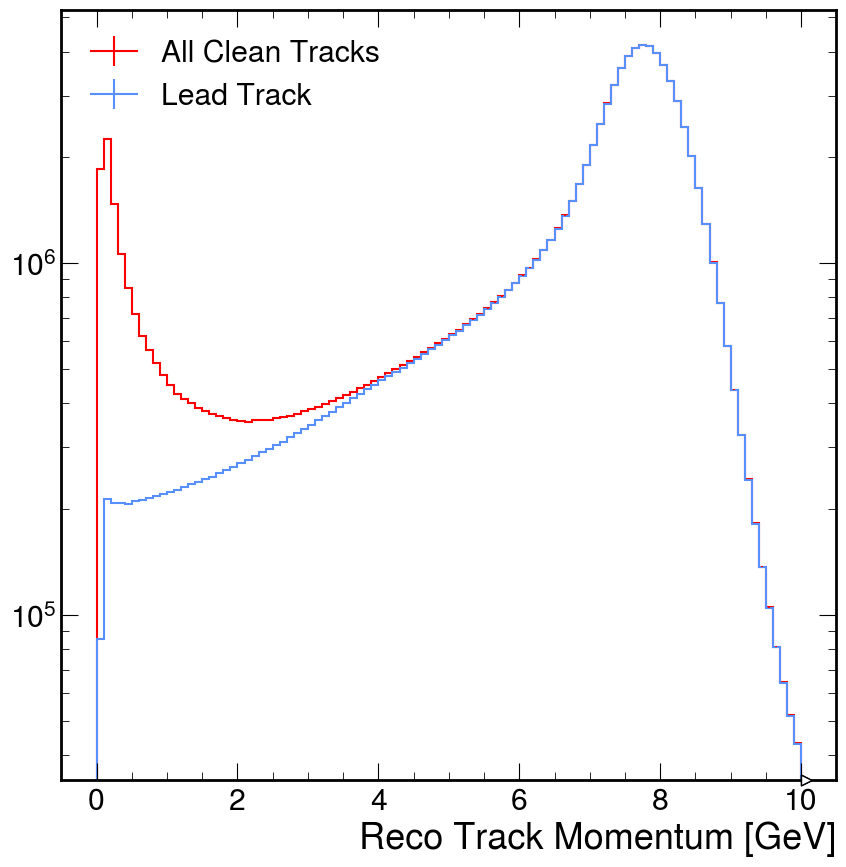

In [12]:
hh = f['reco_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "All Clean Tracks")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track")
plt.legend(loc='best')
plt.xlabel('Reco Track Momentum [GeV]')
#plt.ylim(0,5000)
plt.yscale("log")
#plt.savefig("10M_clean_vs_leadtrk_reco_1D_log.jpg")

90.0 3.5999999999999996
75.0 6.0


Text(0, 1, 'Fraction Above')

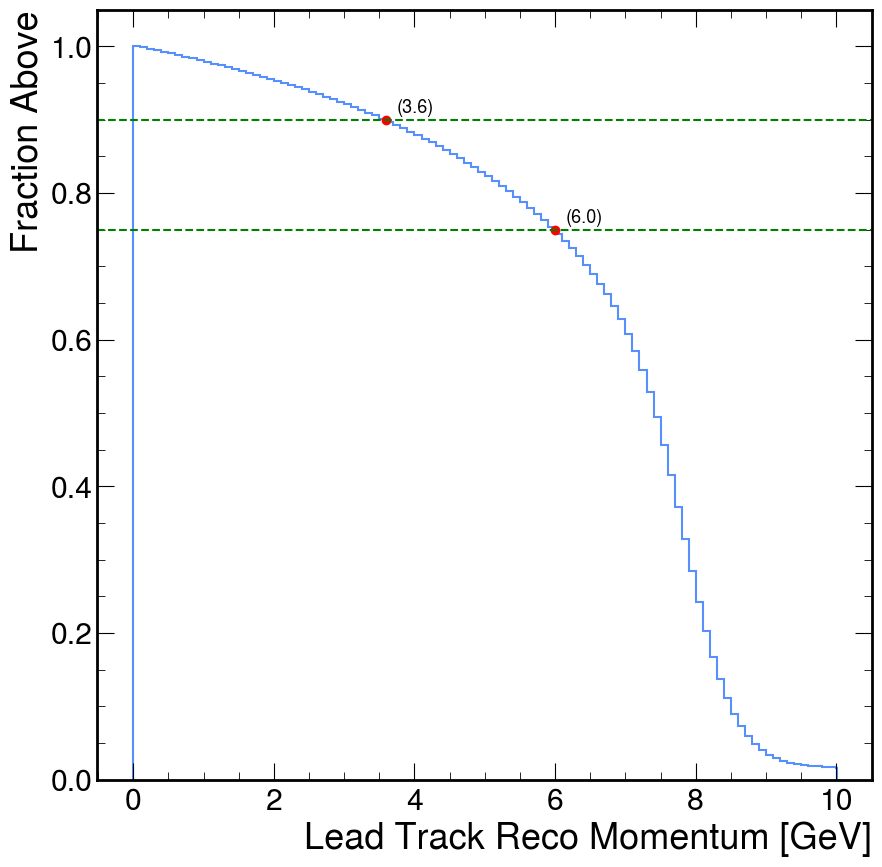

In [13]:
h = f['reco_leadtrk_momentum'].to_hist()
import numpy as np

fraction_above = np.flip(np.cumsum(np.flip(h.values(flow=True))))/np.sum(h.values(flow=True))
momentum = np.concatenate(([h.axes[0].edges[0]-0.01],h.axes[0].edges,[h.axes[0].edges[-1]+0.01]))

mplhep.histplot(fraction_above, bins = momentum)

for thresh in (0.9, 0.75):
    first_above = momentum[np.argmin(fraction_above>thresh)]
    print(100*thresh, first_above)
    #plt.annotate(f'(90%, {first_above:.2f} GeV)', (0.9,first_above), va='bottom', ha='left')
    #plt.axvline(first_above, label = " str(first_above) +, color = "r")
    plt.plot(first_above,thresh,'ro') 
    plt.text(first_above+0.15, thresh+0.01, f"({np.round(first_above,decimals=3)})", fontsize=13)
    plt.axhline(thresh, color = "g", linestyle='--')

plt.xlabel('Lead Track Reco Momentum [GeV]')
plt.ylabel('Fraction Above')
#plt.legend(loc= "best")
#plt.savefig("cumsum_plot.jpg")

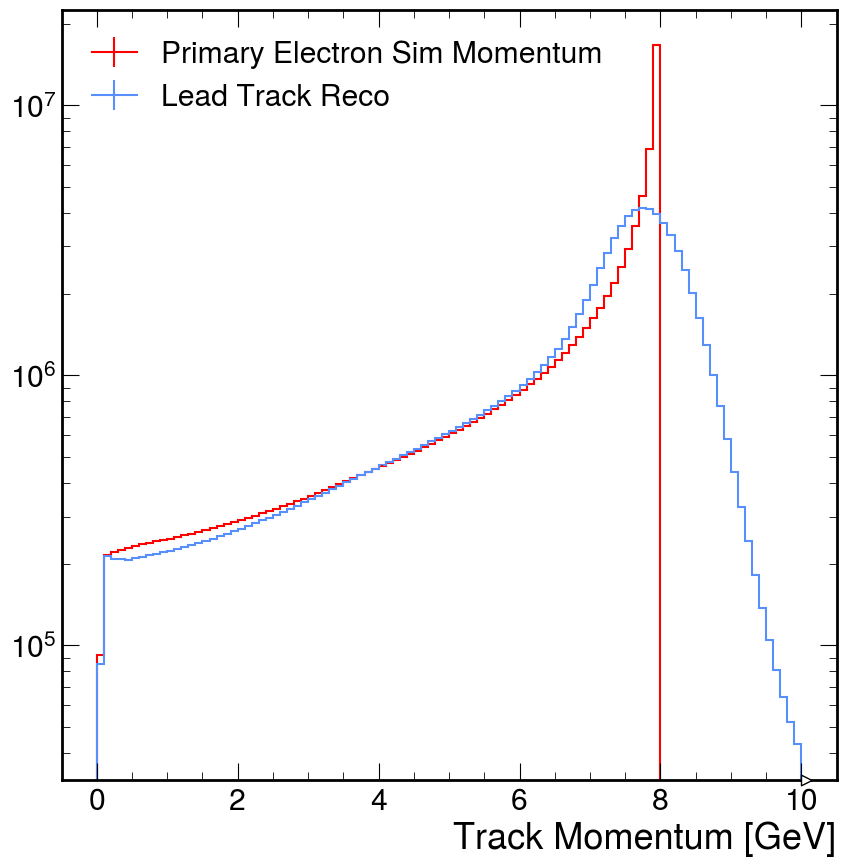

In [14]:
hh = f['esph_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "Primary Electron Sim Momentum")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track Reco")
#d = f['reco_momentum'].to_hist().plot(label = "Clean Tracks")
plt.legend(loc='best')
plt.xlabel('Track Momentum [GeV]')
plt.yscale("log")
#plt.savefig("100M_sim_vs_lead_reco_1D-log.jpg")

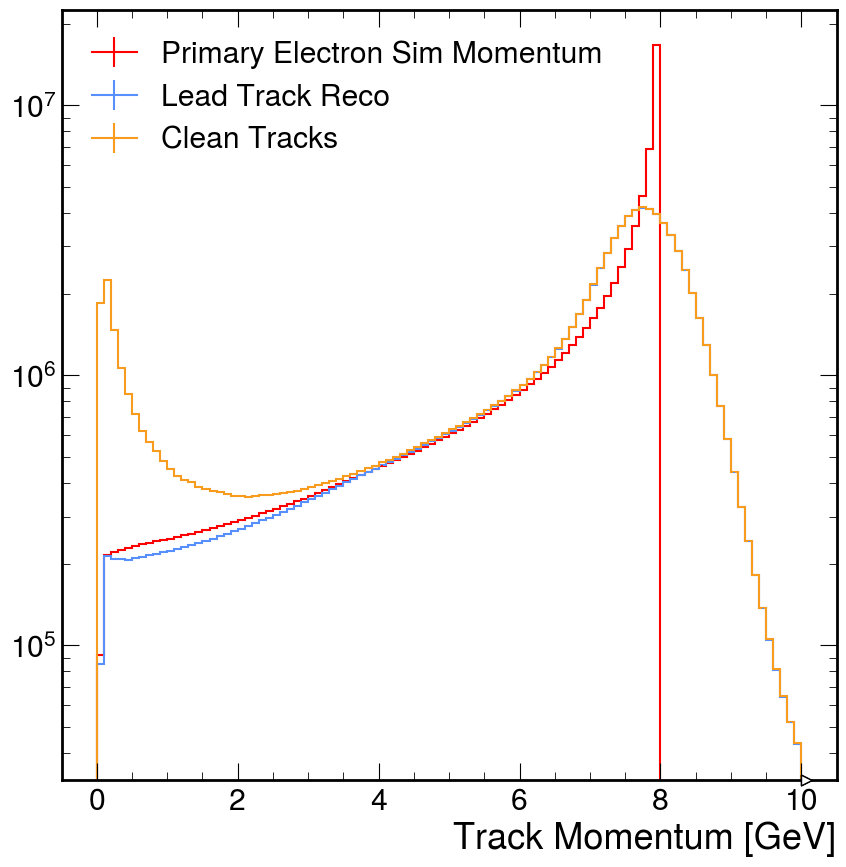

In [15]:
hh = f['esph_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "Primary Electron Sim Momentum")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track Reco")
d = f['reco_momentum'].to_hist().plot(label = "Clean Tracks")
plt.legend(loc='best')
plt.xlabel('Track Momentum [GeV]')
plt.yscale("log")
#plt.savefig("sim_clean_vs_lead_reco_1D-log-sample.jpg")

(-70.0, 70.0)

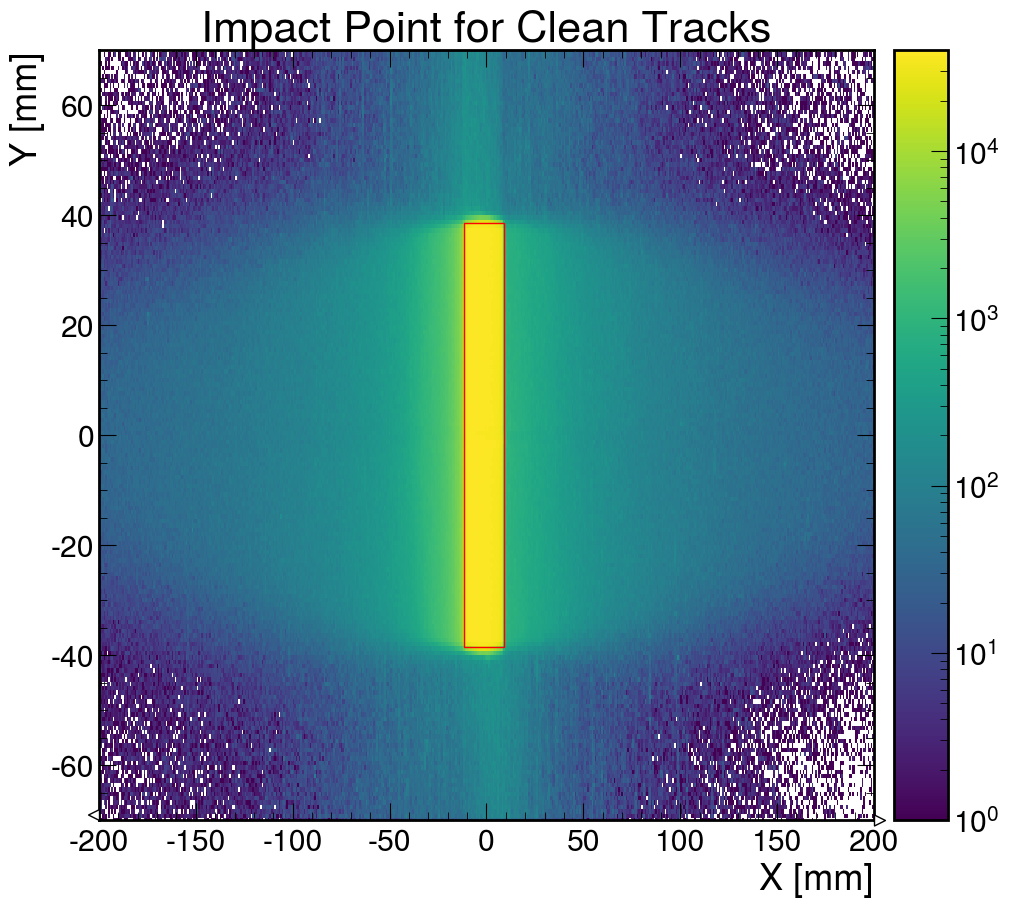

In [16]:
f['impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Clean Tracks")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.ylim(-70,70)
#plt.savefig("100M_impact_point_clean_tracks.jpg")

(-70.0, 70.0)

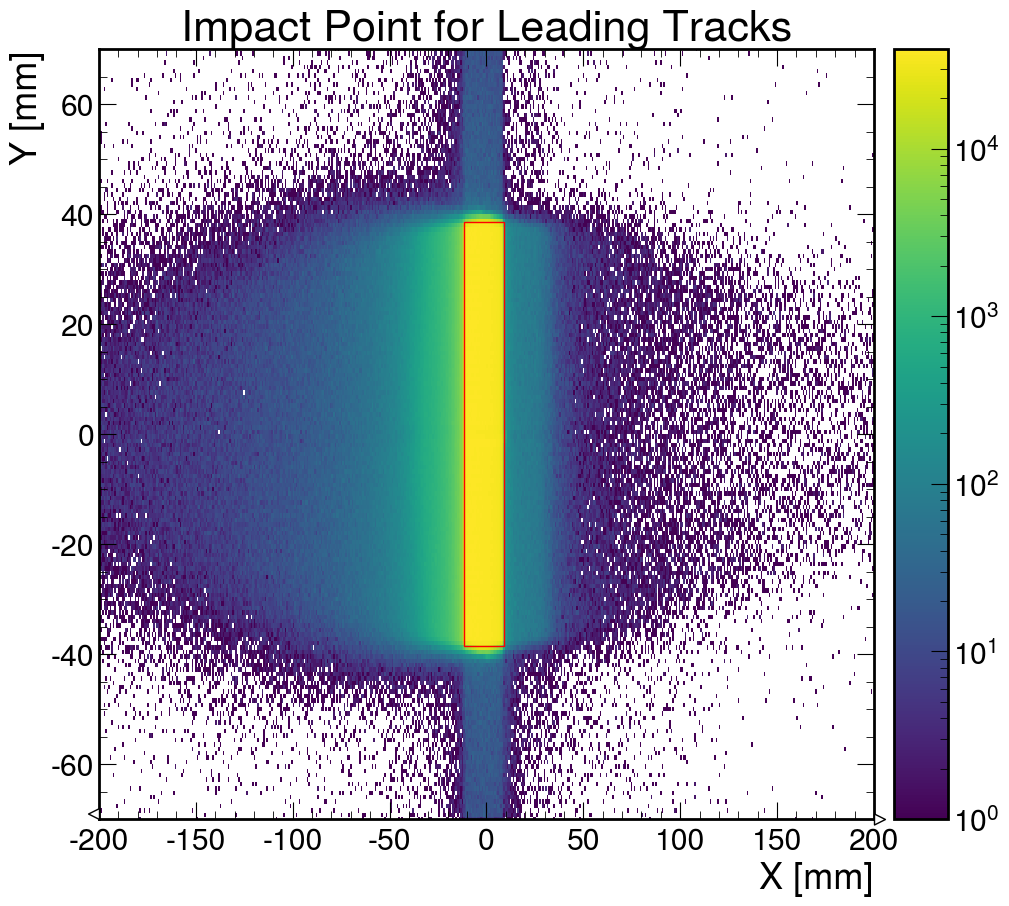

In [17]:
f['leadtrk_impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Leading Tracks")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.ylim(-70,70)
#plt.show()
#plt.savefig("leadtrk_tracks_impact_point_100M.jpg")

(-70.0, 70.0)

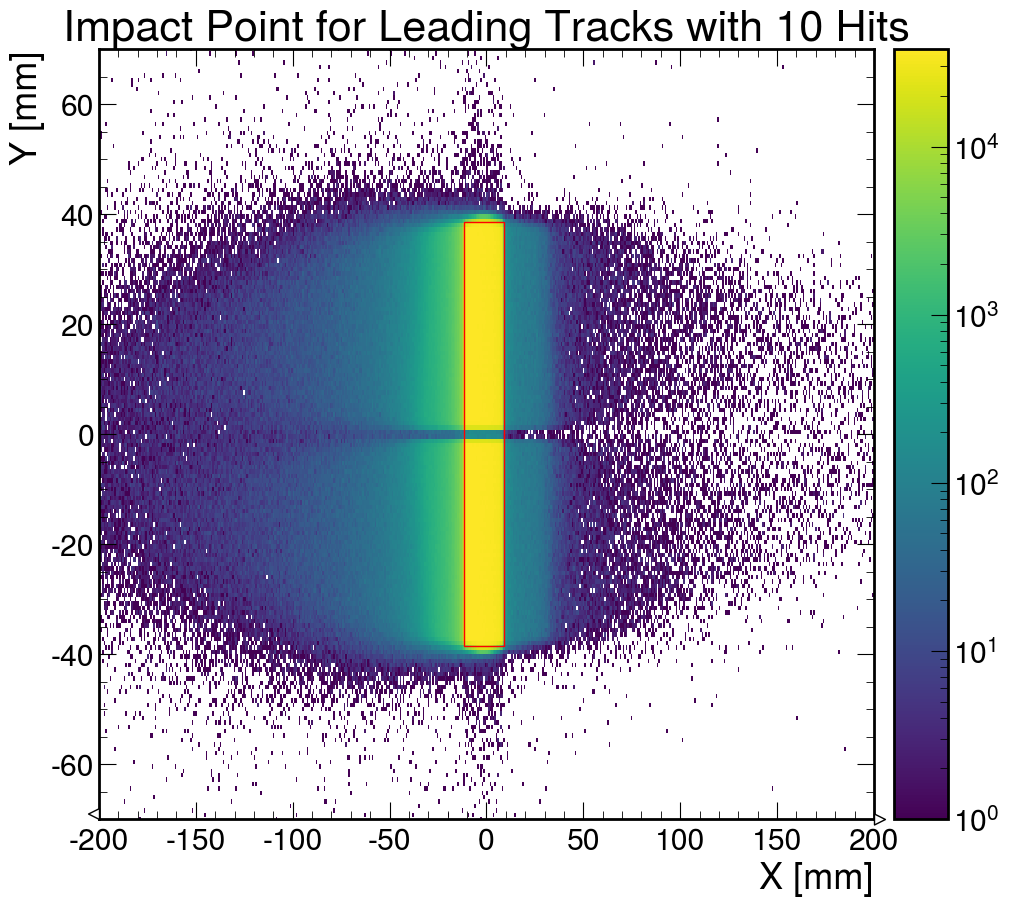

In [18]:
f['leadtrk_nhits_10_impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Leading Tracks with 10 Hits")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.ylim(-70,70)
#plt.show()
#plt.savefig("leadtrk_tracks_impact_point_10hits_100M.jpg")

(-70.0, 70.0)

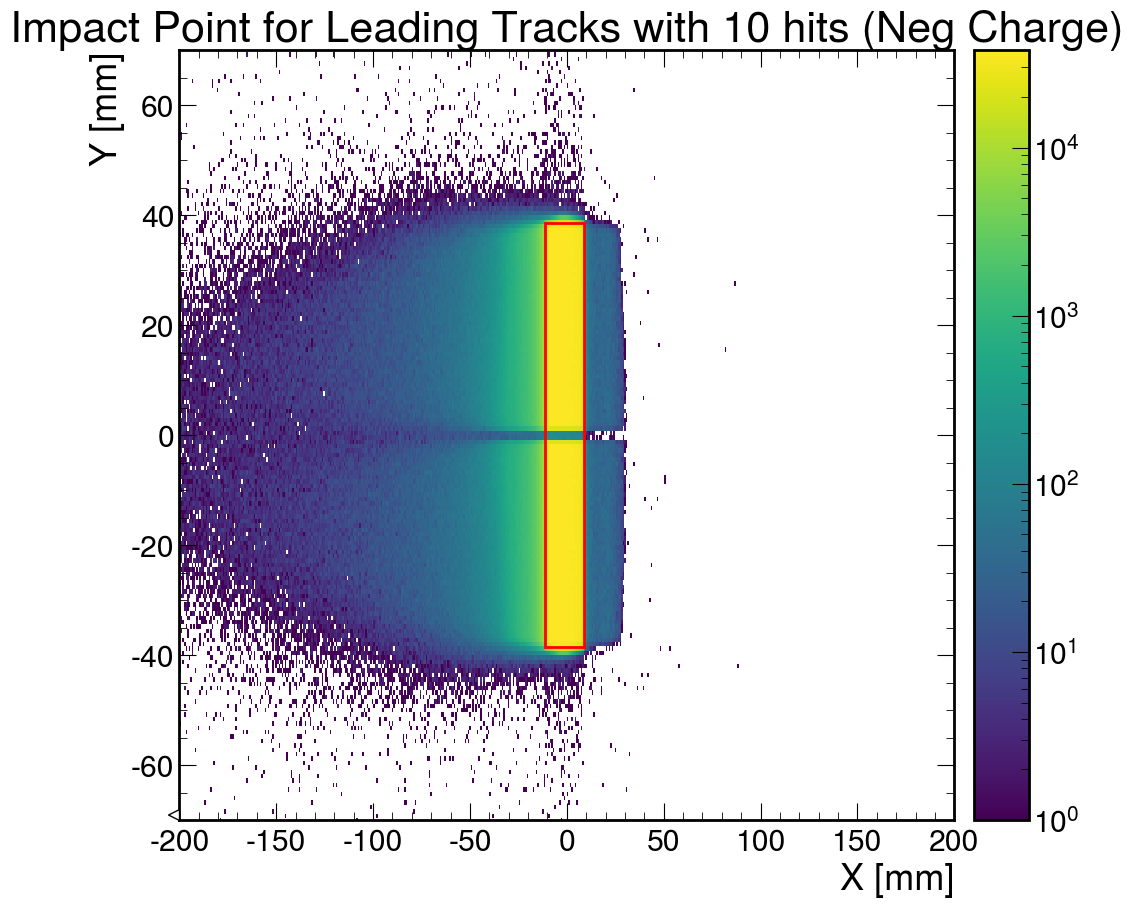

In [19]:
f['leadtrk_nhits_10_neg_charge_impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Leading Tracks with 10 hits (Neg Charge)")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=2, edgecolor='r', facecolor='none')
blect = patches.Rectangle((-20, -50), 40, 100, linewidth=1, edgecolor='black', facecolor='none')
ax.add_patch(rect)
plt.ylim(-70,70)
#ax.add_patch(blect)
#plt.show()
#plt.savefig("leadtrk_tracks_impact_point_10hits_neg_charge_10M.jpg")

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f967ed11df0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f967e924080>, text=[])

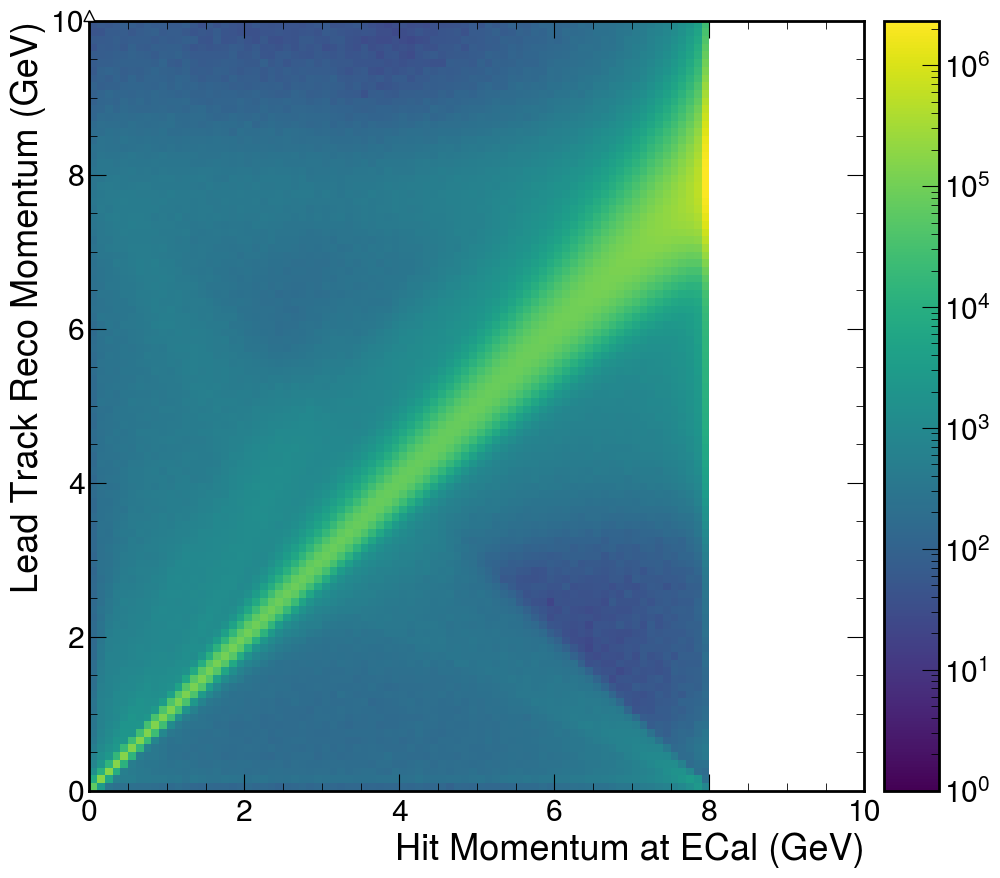

In [21]:
h=f['leadtrk_reco_vs_esph_momentum'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
#plt.title("Lead Track")
h.plot(cmin=1, norm='log')
#plt.axhline(8)


#plt.axline((0, 0), slope=1,color="red", linestyle="--", label="y = x")
#.axline((8, 0), slope=-1,color="black", linestyle="--")
#plt.show()
#plt.savefig("leadtrk_reco_vs_esph_momentum_10M.jpg")

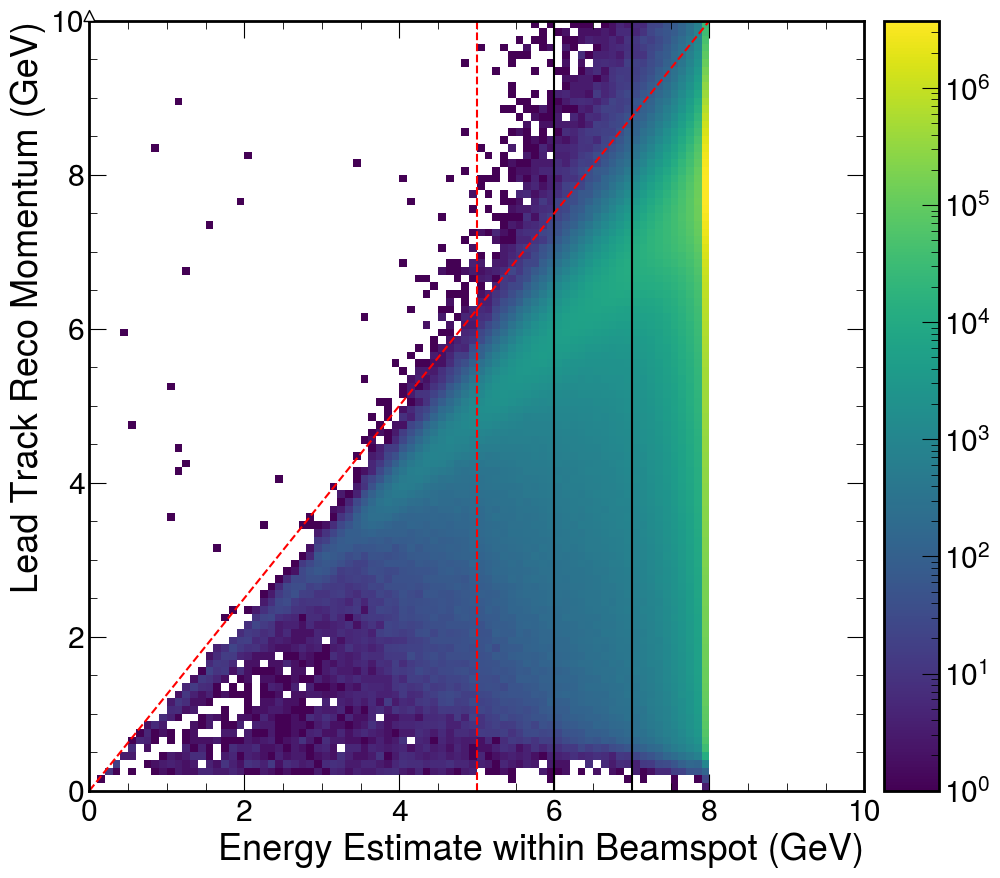

In [27]:
h=f['leadtrk_reco_all_reqs_vs_Energy_Estimate_Beamspot'].to_hist()

h.plot(cmin=1, norm="log") #flow='show')

plt.axvline(5, color='red', linestyle='--')
plt.axvline(6, color='black')
plt.axvline(7,color ='black')

plt.axline((0, 0), slope=1.25,color="red", linestyle="--")

#plt.savefig("skimming_zones_100M-cuts.jpg")

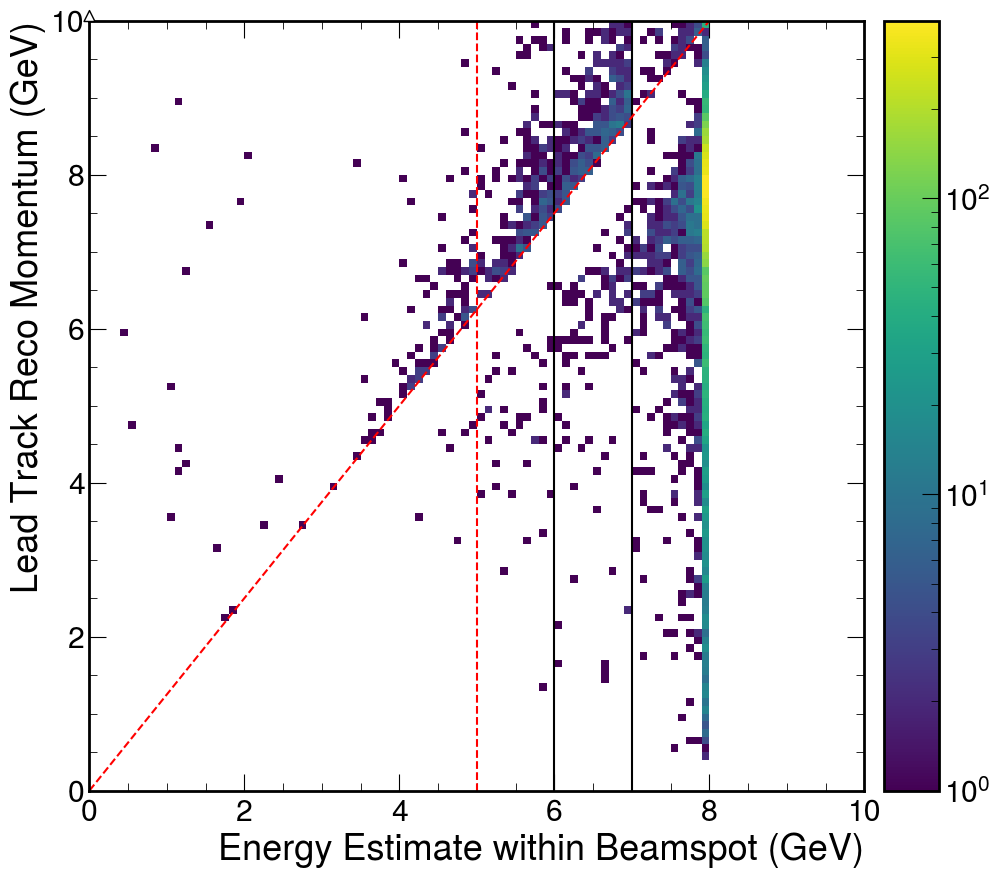

In [31]:
h=f['skim_zone_leadtrk_reco_all_reqs_vs_energy_estimate_beamspot'].to_hist()

h.plot(cmin=1, norm="log") #flow='show')

plt.axvline(5, color='red', linestyle='--')
plt.axvline(6, color='black')
plt.axvline(7,color ='black')

plt.axline((0, 0), slope=1.25,color="red", linestyle="--")

plt.savefig("skimming_zones_100M-cuts-v2.jpg")

In [28]:
h=f['skim_zone_leadtrk_reco_all_reqs_vs_energy_estimate_beamspot'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
#plt.title("Lead Track")
#plt.axvline(5, color='red', linestyle='--')
#plt.axvline(6, color='black')
#plt.axvline(7,color ='black')

#plt.axline((0, 0), slope=1.25,color="red", linestyle="--")

plt.show()
#plt.savefig("SkimZone-Sample.jpg")